In [ ]:
# Graph RAG Lesson 1
%pip install -q -U networkx matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 64.8 MB/s eta 0:00:00


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
def draw_graph(G, title, node_colors=None, figsize=(11,7), seed=7, node_size=1700):
  pos = nx.spring_layout(G, seed=seed, k=0.9)
  plt.figure(figsize=figsize)
  plt.title(title)
  nx.draw_networkx_nodes(G, pos, node_color=node_colors or '#8ecae6',
                           node_size=node_size, alpha=0.95, edgecolors='#023047')
  nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=16,
                           edge_color='#adb5bd', width=1.4)
  nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
  edge_labels = nx.get_edge_attributes(G, 'label')
  if edge_labels:
      nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                     font_size=7, font_color='#d90429')
  plt.title(title, fontsize=13, fontweight='bold')
  plt.axis('off')
  plt.tight_layout()
  plt.show()

print('networkx version :', nx.__version__)
print('draw_graph() helper ready')


networkx version : 3.6.1
draw_graph() helper ready


In [ ]:
# minimal graph with properties

pg = nx.DiGraph()
pg.add_node("nolan", label="Person", name="Christopher Nolan", born=1970)
pg.add_node("interstellar", label="Movie", title="Interstellar", rating=9.1, year=2014)

pg.add_edge("nolan", "interstellar", label="DIRECTED", year=2014)

print('Nodes and their properties:')
for node_id, props in pg.nodes(data=True):
    print(f'  ({props["label"]}) {node_id} -> {props}')

print('\nRelationships and their properties:')
for src, dst, props in pg.edges(data=True):
    print(f'  ({src})-[:{props["label"]} {props}]->({dst})')


Nodes and their properties:
  (Person) nolan -> {'label': 'Person', 'name': 'Christopher Nolan', 'born': 1970}
  (Movie) interstellar -> {'label': 'Movie', 'title': 'Interstellar', 'rating': 9.1, 'year': 2014}

Relationships and their properties:
  (nolan)-[:DIRECTED {'label': 'DIRECTED', 'year': 2014}]->(interstellar)


In [ ]:
# 4 types of graphs in production GraphRAG system

"""
1. Domain Graph
2. Community Graph
3. Parent Child
4. Lexical Graph
"""

'\n1. Domain Graph\n2. Community Graph\n3. Parent Child\n4. Lexical Graph\n'

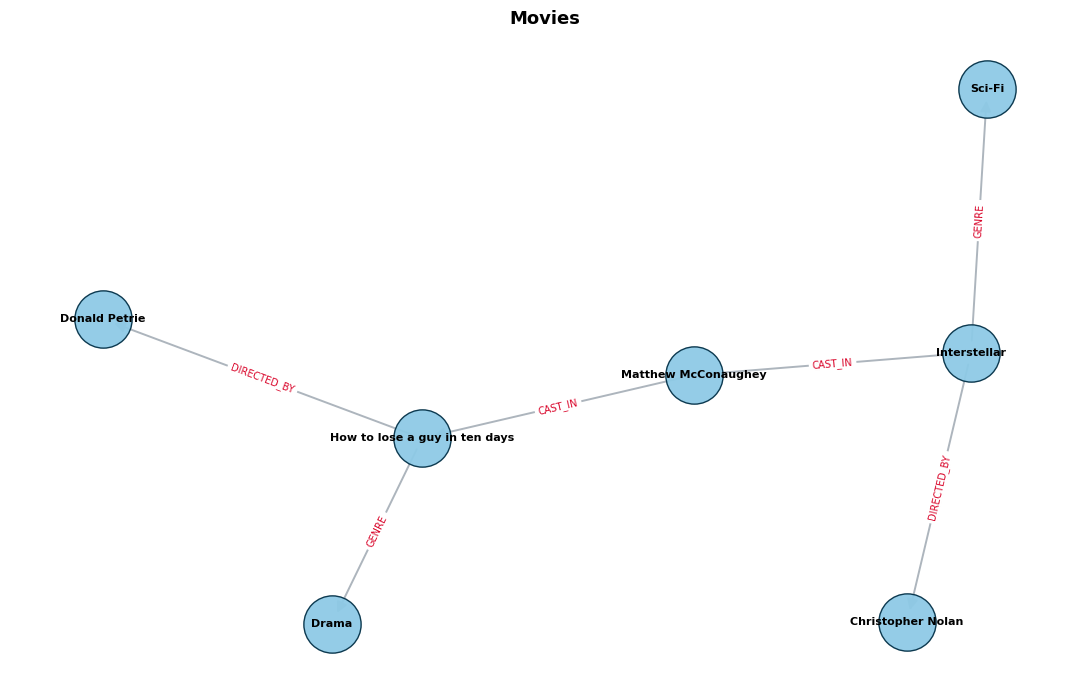

In [ ]:
# domain graph
domain = nx.DiGraph()
domain.add_edge("Matthew McConaughey", "Interstellar", label="CAST_IN")
domain.add_edge("Matthew McConaughey", "How to lose a guy in ten days", label="CAST_IN")
domain.add_edge("Interstellar", "Christopher Nolan", label="DIRECTED_BY")
domain.add_edge("How to lose a guy in ten days", "Donald Petrie", label="DIRECTED_BY")
domain.add_edge("Interstellar", "Sci-Fi", label="GENRE")
domain.add_edge("How to lose a guy in ten days", "Drama", label="GENRE")

draw_graph(domain, "Movies")

In [ ]:
# multi-hop traversal
for movie in domain.successors("Matthew McConaughey"):
  for target in domain.successors(movie):
    if domain.edges[movie, target]["label"] == "DIRECTED_BY":
      print(f'  {movie} directed by {target}')

  Interstellar directed by Christopher Nolan
  How to lose a guy in ten days directed by Donald Petrie


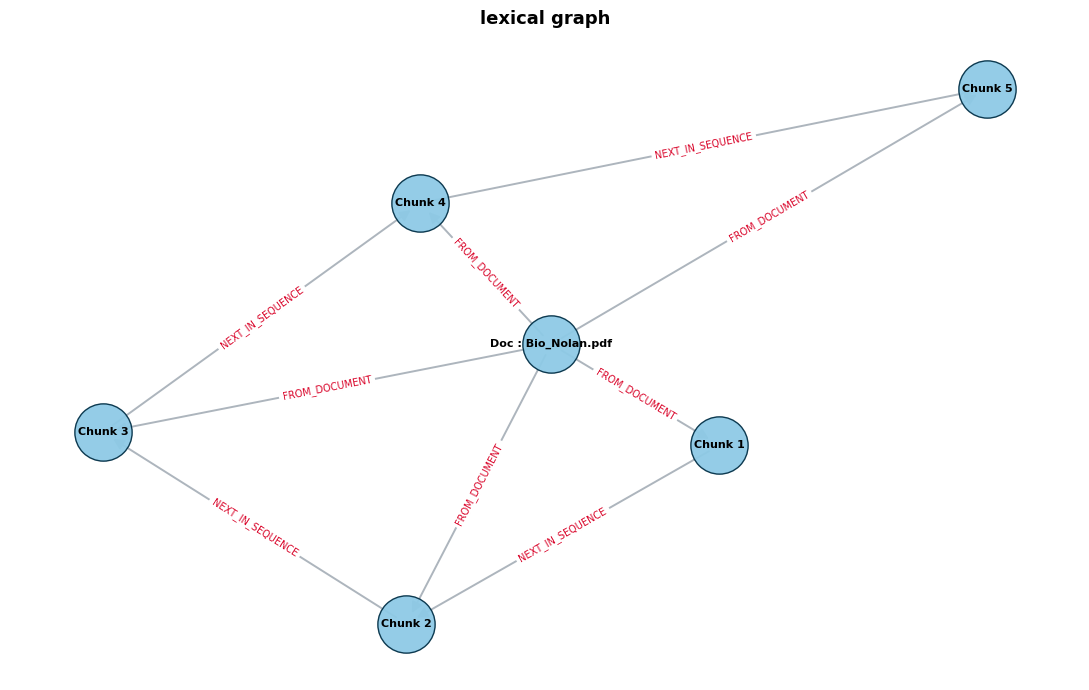

Each Chunk stores an embedding used by the VECTOR INDEX, e.g.: [vector_0...]


In [ ]:
# lexical graph
# 2 important nodes - document and chunk
# for information retrieval

lexical = nx.DiGraph()
chunks = ["Chunk 1", "Chunk 2", "Chunk 3", "Chunk 4", "Chunk 5"]
for ch in chunks:
  lexical.add_edge("Doc : Bio_Nolan.pdf", ch, label="FROM_DOCUMENT")
for a, b in zip(chunks, chunks[1:]):
  lexical.add_edge(a,b, label="NEXT_IN_SEQUENCE")
for i, ch in enumerate(chunks):
  lexical.nodes[ch]["embedding"] = f'[vector_{i}...]'
draw_graph(lexical, "lexical graph")
print('Each Chunk stores an embedding used by the VECTOR INDEX, e.g.:',
      lexical.nodes['Chunk 1']['embedding'])


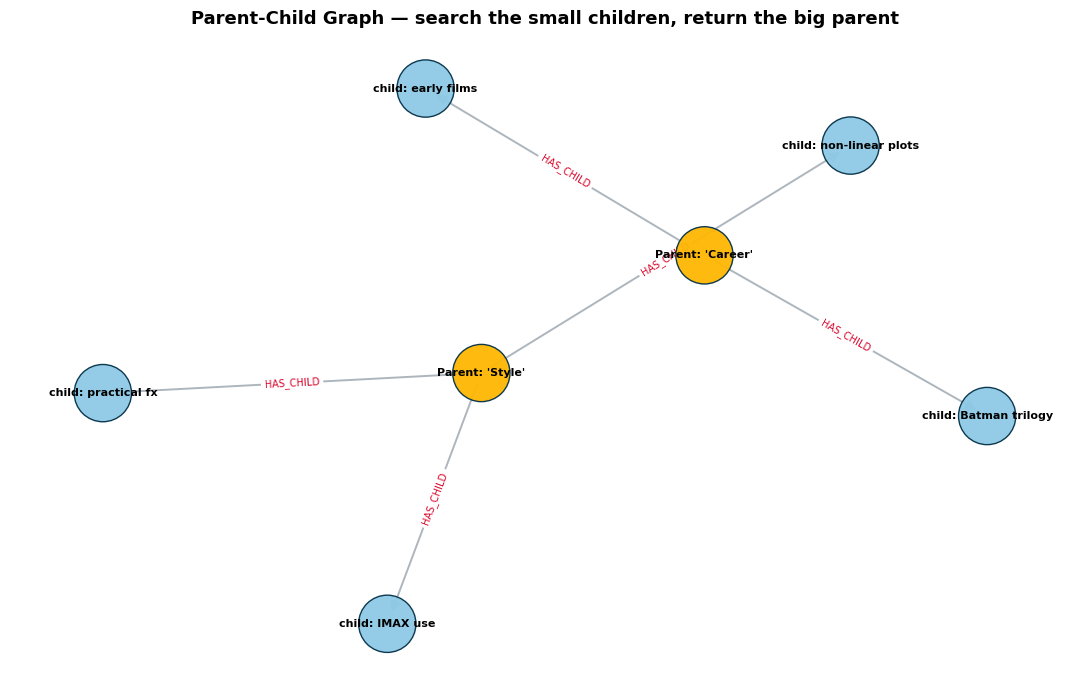

Vector search matched the child: "child: IMAX use"
  -> return its parent to the LLM for context: "Parent: 'Style'"


In [ ]:
# Parent - Child graphs are used for retrieving context.
# Parent - more context to the LLM.
# Child - Used for searching

pc = nx.DiGraph()
hierarchy = {
    "Parent: 'Career'": ['child: early films', 'child: Batman trilogy'],
    "Parent: 'Style'":  ['child: practical fx', 'child: non-linear plots', 'child: IMAX use'],
}
for parent, children in hierarchy.items():
    for child in children:
        pc.add_edge(parent, child, label='HAS_CHILD')

colors = ['#ffb703' if pc.out_degree(n) > 0 else '#8ecae6' for n in pc.nodes()]
draw_graph(pc, 'Parent-Child Graph — search the small children, return the big parent',
           node_colors=colors)

# Simulate the pattern: a child matches -> we return its PARENT for richer context
matched_child = 'child: IMAX use'
parent = next(iter(pc.predecessors(matched_child)))
print(f'Vector search matched the child: "{matched_child}"')
print(f'  -> return its parent to the LLM for context: "{parent}"')

Detected 2 communities via Louvain:
  Community 0: ['Dunkirk', 'Inception', 'Interstellar', 'Nolan']
  Community 1: ['Aliens', 'Avatar', 'Cameron', 'Titanic']


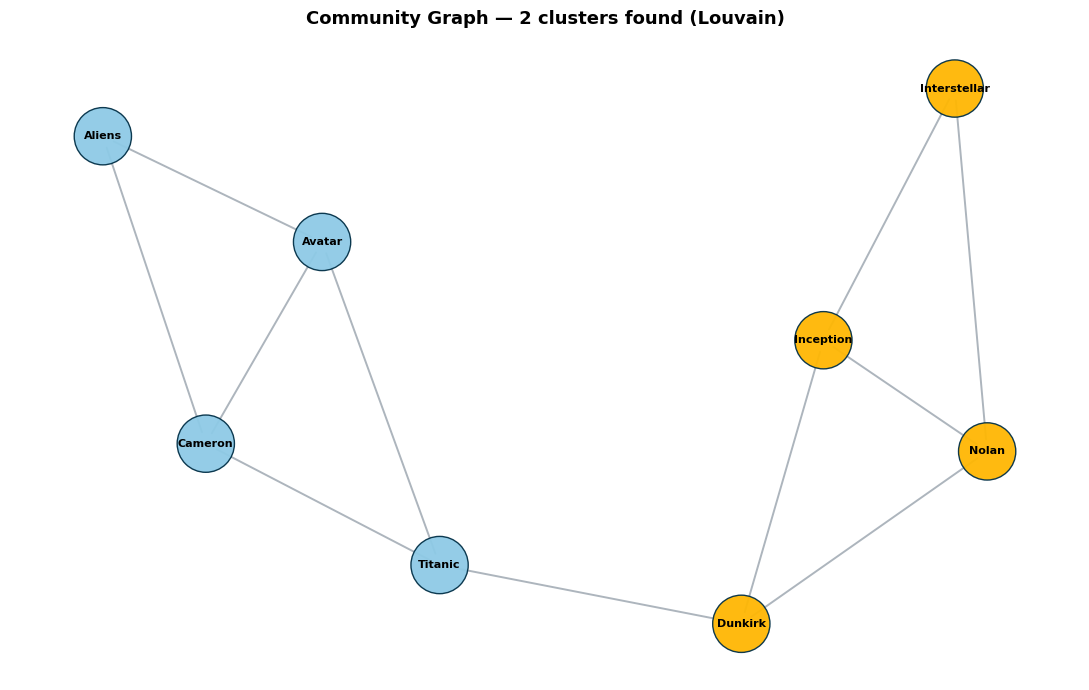

In [ ]:
comm = nx.Graph()
# Cluster 1 (Nolan-ish)
comm.add_edges_from([('Inception', 'Interstellar'), ('Interstellar', 'Nolan'),
                     ('Inception', 'Nolan'), ('Nolan', 'Dunkirk'), ('Inception', 'Dunkirk')])
# Cluster 2 (Cameron-ish)
comm.add_edges_from([('Titanic', 'Avatar'), ('Avatar', 'Cameron'),
                     ('Titanic', 'Cameron'), ('Cameron', 'Aliens'), ('Avatar', 'Aliens')])
# A weak bridge between the two clusters
comm.add_edge('Dunkirk', 'Titanic')

# Community detection (Louvain if available, else greedy modularity)
try:
    from networkx.algorithms.community import louvain_communities
    communities = louvain_communities(comm, seed=42)
    method = 'Louvain'
except Exception:
    from networkx.algorithms.community import greedy_modularity_communities
    communities = [set(c) for c in greedy_modularity_communities(comm)]
    method = 'greedy modularity'

print(f'Detected {len(communities)} communities via {method}:')
for i, c in enumerate(communities):
    print(f'  Community {i}: {sorted(c)}')
# Colour nodes by their detected community
palette = ['#ffb703', '#8ecae6', '#90be6d', '#f4978e', '#cdb4db']
node_color = {}
for i, c in enumerate(communities):
    for node in c:
        node_color[node] = palette[i % len(palette)]
draw_graph(comm, f'Community Graph — {len(communities)} clusters found ({method})',
           node_colors=[node_color[n] for n in comm.nodes()])

In [ ]:
"""Domain: Add a Kate Winslet -[:CAST_IN]-> Titanic edge to a new domain graph, then find every person connected to Titanic.
Lexical: Create a document with 5 chunks linked by NEXT_CHUNK; print the reading order by traversing the edges.
Parent–child: Model Document → Section → Paragraph (3 levels) and, given a paragraph, walk up to its document.
Community: Add a third dense cluster to the community example and re-run detection — how many communities are found now?"""

domain.add_edge("Kate Hudson", "How to lose a guy in ten days", label="CAST_IN")
for people in domain.predecessors("How to lose a guy in ten days"):
  print(people)

Matthew McConaughey
Kate Hudson
